# Experiment 3: ResNet50 Fine-tuning (Last Block)

## Hypothesis

Building on Experiment 2 (frozen ResNet50, 92.69% test accuracy), this
experiment unfreezes the last residual block of ResNet50 (conv5_block3)
and continues training with a 100x smaller learning rate. This should
allow the model to specialize ImageNet features for waste classification,
particularly addressing the persistent plastic <-> glass confusion.

Expected gain: +1-3 percentage points over Experiment 2.

## Configuration

Two-phase training:

Phase 1: classifier head only (warm-up)
- Same as Experiment 2: lr=1e-3, frozen base
- Max 15 epochs, EarlyStopping patience=5

Phase 2: classifier + conv5_block3
- lr=1e-5 (100x lower)
- BatchNorm layers stay frozen even within unfrozen block
- Max 20 epochs, EarlyStopping patience=7

## Why this approach

- Phase 1 lets the classifier converge before backpropagating into the base
- Phase 2 lr is much lower because pretrained weights need only small nudges
- Only the last block is unfrozen because earlier blocks learn universal
  features (edges, textures) that should remain unchanged
- BatchNorm running stats are preserved to avoid disrupting feature scales

In [16]:
import os
import shutil

if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

!git clone https://github.com/wayofell/trash-classification.git
%cd trash-classification

import sys
sys.path.insert(0, '.')

import tensorflow as tf
print(f"TF version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Cloning into 'trash-classification'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 59 (delta 23), reused 47 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 4.54 MiB | 23.61 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/kaggle/working/trash-classification
TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
from src.data import load_dataset, CLASS_NAMES, NUM_CLASSES
from src.model import build_resnet50_transfer, unfreeze_last_block
from src.train import compile_and_train, evaluate_on_test
from src.utils import (
    log_experiment, plot_training_curves,
    collect_predictions, plot_confusion_matrix, print_classification_report,
    get_experiments_dir
)

print("All imports OK")

All imports OK


In [19]:
BATCH_SIZE = 32

train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=BATCH_SIZE)

print("Dataset sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples ({n // BATCH_SIZE} batches)")

Dataset sizes:
  train:  8593 samples (268 batches)
  val  :  1833 samples (57 batches)
  test :  1833 samples (57 batches)


## Phase 1: Train classifier head with frozen base

This replicates Experiment 2 — we need the classifier to converge before
unfreezing the base, otherwise random gradients would propagate through
and damage the pretrained ImageNet weights.

In [21]:
model = build_resnet50_transfer(trainable_base=False)

print("Phase 1: classifier head only")
trainable_p1 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable parameters: {trainable_p1:,}")
print(f"Total parameters: {model.count_params():,}\n")

PHASE1_EPOCHS = 15
PHASE1_LR = 1e-3

history_p1, time_p1 = compile_and_train(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=PHASE1_EPOCHS,
    learning_rate=PHASE1_LR,
    optimizer_name="adam",
    class_weight=None,
    verbose=2,
)

print(f"\nPhase 1 finished in {time_p1:.1f} sec ({time_p1/60:.1f} min)")
print(f"Phase 1 best val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

Phase 1: classifier head only
Trainable parameters: 20,490
Total parameters: 23,608,202

Epoch 1/15
269/269 - 34s - 128ms/step - accuracy: 0.7947 - loss: 0.6148 - val_accuracy: 0.8974 - val_loss: 0.3149 - learning_rate: 1.0000e-03
Epoch 2/15
269/269 - 14s - 53ms/step - accuracy: 0.9041 - loss: 0.2983 - val_accuracy: 0.9111 - val_loss: 0.2854 - learning_rate: 1.0000e-03
Epoch 3/15
269/269 - 14s - 52ms/step - accuracy: 0.9139 - loss: 0.2485 - val_accuracy: 0.9089 - val_loss: 0.2903 - learning_rate: 1.0000e-03
Epoch 4/15
269/269 - 14s - 52ms/step - accuracy: 0.9261 - loss: 0.2134 - val_accuracy: 0.9143 - val_loss: 0.2707 - learning_rate: 1.0000e-03
Epoch 5/15
269/269 - 14s - 53ms/step - accuracy: 0.9329 - loss: 0.1968 - val_accuracy: 0.9198 - val_loss: 0.2576 - learning_rate: 1.0000e-03
Epoch 6/15
269/269 - 14s - 52ms/step - accuracy: 0.9341 - loss: 0.1844 - val_accuracy: 0.9193 - val_loss: 0.2500 - learning_rate: 1.0000e-03
Epoch 7/15
269/269 - 14s - 53ms/step - accuracy: 0.9429 - loss: 

## Phase 2: Unfreeze last block and continue with low LR

We now unfreeze conv5_block3 of ResNet50 — the last residual block.
Critical details:
- Learning rate dropped to 1e-5 (100x lower than Phase 1)
- BatchNorm layers within the block stay frozen
- EarlyStopping patience increased to 7 (fine-tuning is slower)

In [22]:
from src.train import get_default_callbacks

# Unfreeze the last block
n_unfrozen = unfreeze_last_block(model, block_name="conv5_block3")
print(f"Layers unfrozen: {n_unfrozen}")

trainable_p2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable parameters now: {trainable_p2:,}")
print(f"Multiplier vs Phase 1: {trainable_p2 / trainable_p1:.1f}x more parameters trainable\n")

# Re-compile with new optimizer (lower LR) — this is required after changing trainability
PHASE2_LR = 1e-5
PHASE2_EPOCHS = 20

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# Custom callbacks for fine-tuning (longer patience)
callbacks_p2 = get_default_callbacks(
    early_stopping_patience=7,
    lr_reduce_patience=4,
)

import time
start = time.time()
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    verbose=2,
)
time_p2 = time.time() - start

print(f"\nPhase 2 finished in {time_p2:.1f} sec ({time_p2/60:.1f} min)")
print(f"Phase 2 best val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

Layers unfrozen: 7
Trainable parameters now: 4,480,010
Multiplier vs Phase 1: 218.6x more parameters trainable

Epoch 1/20
269/269 - 36s - 135ms/step - accuracy: 0.9522 - loss: 0.1371 - val_accuracy: 0.9285 - val_loss: 0.2384 - learning_rate: 1.0000e-05
Epoch 2/20
269/269 - 15s - 57ms/step - accuracy: 0.9618 - loss: 0.1111 - val_accuracy: 0.9258 - val_loss: 0.2465 - learning_rate: 1.0000e-05
Epoch 3/20
269/269 - 15s - 57ms/step - accuracy: 0.9636 - loss: 0.1030 - val_accuracy: 0.9318 - val_loss: 0.2308 - learning_rate: 1.0000e-05
Epoch 4/20
269/269 - 15s - 57ms/step - accuracy: 0.9699 - loss: 0.0894 - val_accuracy: 0.9324 - val_loss: 0.2378 - learning_rate: 1.0000e-05
Epoch 5/20
269/269 - 15s - 57ms/step - accuracy: 0.9749 - loss: 0.0770 - val_accuracy: 0.9302 - val_loss: 0.2368 - learning_rate: 1.0000e-05
Epoch 6/20
269/269 - 15s - 57ms/step - accuracy: 0.9754 - loss: 0.0718 - val_accuracy: 0.9318 - val_loss: 0.2493 - learning_rate: 1.0000e-05
Epoch 7/20

Epoch 7: ReduceLROnPlateau re

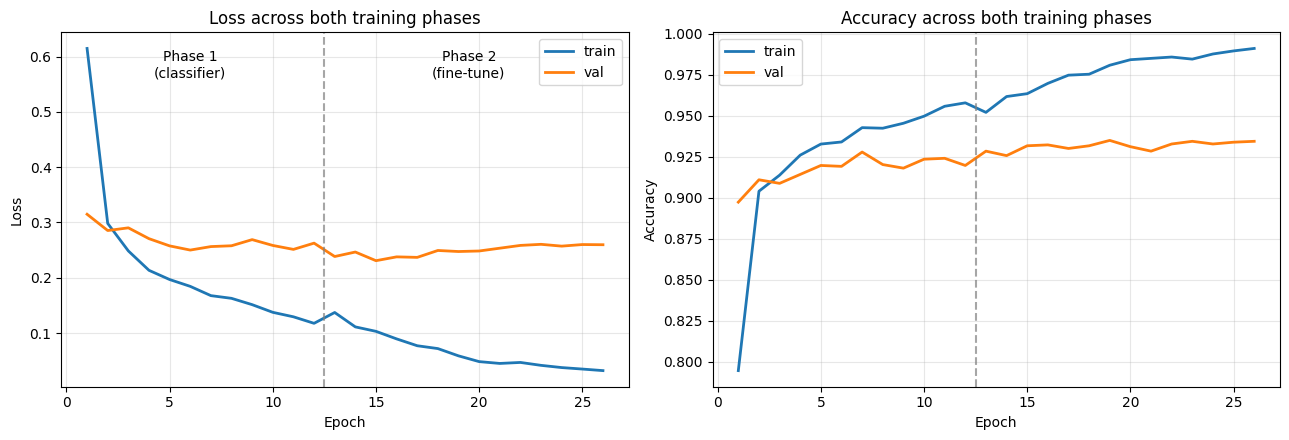

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Combine histories for one unified plot
def combine_histories(*histories):
    combined = {}
    for h in histories:
        for k, v in h.history.items():
            combined.setdefault(k, []).extend(v)
    return combined

combined = combine_histories(history_p1, history_p2)
phase1_end = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_total = range(1, len(combined['loss']) + 1)

# Loss
axes[0].plot(epochs_total, combined['loss'], label='train', linewidth=2)
axes[0].plot(epochs_total, combined['val_loss'], label='val', linewidth=2)
axes[0].axvline(phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].text(phase1_end / 2, axes[0].get_ylim()[1] * 0.95,
             'Phase 1\n(classifier)', ha='center', va='top', fontsize=10)
axes[0].text(phase1_end + (len(combined['loss']) - phase1_end) / 2 + 0.5,
             axes[0].get_ylim()[1] * 0.95,
             'Phase 2\n(fine-tune)', ha='center', va='top', fontsize=10)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss across both training phases')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_total, combined['accuracy'], label='train', linewidth=2)
axes[1].plot(epochs_total, combined['val_accuracy'], label='val', linewidth=2)
axes[1].axvline(phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy across both training phases')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plots_dir = get_experiments_dir() / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / "03_resnet50_finetune_curves.png", bbox_inches='tight', dpi=150)
plt.show()

In [24]:
test_loss, test_acc = evaluate_on_test(model, test_ds)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")

# Compare to previous experiments
print(f"\n--- Comparison to previous experiments ---")
print(f"Baseline CNN:          78.61%")
print(f"ResNet50 frozen:       92.69%  (+14.08 pp over baseline)")
print(f"ResNet50 fine-tuned:   {test_acc * 100:.2f}%  "
      f"({(test_acc - 0.9269) * 100:+.2f} pp over frozen)")

Test loss:     0.2070
Test accuracy: 0.9329 (93.29%)

--- Comparison to previous experiments ---
Baseline CNN:          78.61%
ResNet50 frozen:       92.69%  (+14.08 pp over baseline)
ResNet50 fine-tuned:   93.29%  (+0.60 pp over frozen)


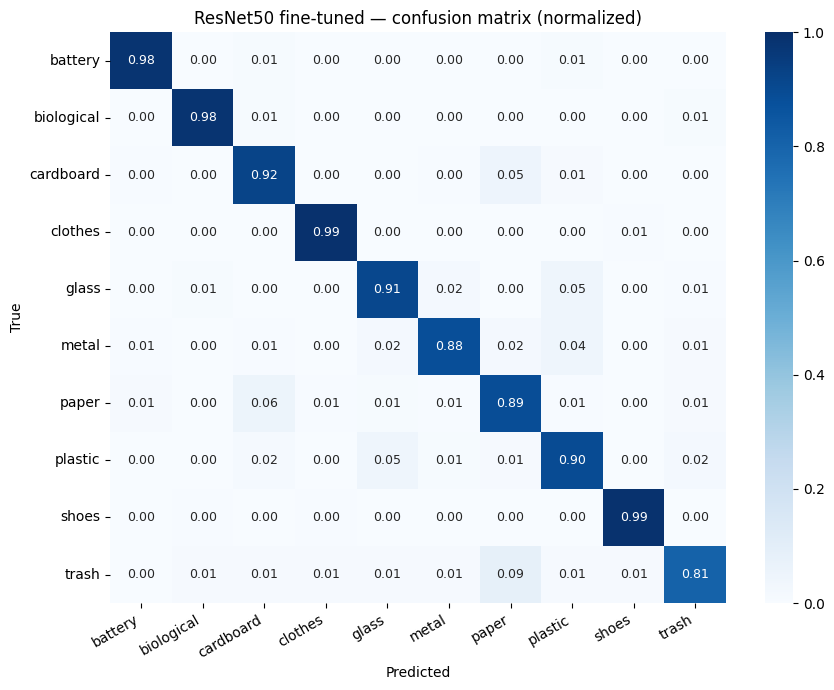

In [25]:
y_true, y_pred = collect_predictions(model, test_ds)

cm = plot_confusion_matrix(
    y_true, y_pred,
    class_names=CLASS_NAMES,
    title="ResNet50 fine-tuned — confusion matrix (normalized)",
    normalize=True,
    save_path=plots_dir / "03_resnet50_finetune_confusion.png"
)

In [26]:
from sklearn.metrics import f1_score

report = print_classification_report(y_true, y_pred, CLASS_NAMES)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"vs Experiment 2 frozen (0.9196): {(macro_f1 - 0.9196):+.4f}")

              precision    recall  f1-score   support

     battery      0.957     0.982     0.969       113
  biological      0.953     0.981     0.967       104
   cardboard      0.911     0.924     0.918       211
     clothes      0.989     0.993     0.991       283
       glass      0.933     0.912     0.922       260
       metal      0.918     0.885     0.901       139
       paper      0.886     0.890     0.888       200
     plastic      0.899     0.895     0.897       239
       shoes      0.986     0.991     0.989       217
       trash      0.806     0.806     0.806        67

    accuracy                          0.933      1833
   macro avg      0.924     0.926     0.925      1833
weighted avg      0.933     0.933     0.933      1833


Macro F1: 0.9248
vs Experiment 2 frozen (0.9196): +0.0052


In [27]:
total_epochs = len(history_p1.history['loss']) + len(history_p2.history['loss'])
total_time = time_p1 + time_p2

# Final train metrics come from Phase 2
final_train_acc = history_p2.history['accuracy'][-1]
final_train_loss = history_p2.history['loss'][-1]
best_val_acc = max(history_p2.history['val_accuracy'])
best_val_loss = min(history_p2.history['val_loss'])

log_experiment({
    "experiment_name": "03_resnet50_finetune",
    "model": "resnet50_imagenet_finetune_lastblock",
    "epochs": total_epochs,
    "batch_size": BATCH_SIZE,
    "optimizer": "adam",
    "learning_rate": f"{PHASE1_LR}->{PHASE2_LR}",
    "augmentation": "flip+brightness+contrast",
    "class_weights": "none",
    "train_acc": round(final_train_acc, 4),
    "val_acc": round(best_val_acc, 4),
    "test_acc": round(test_acc, 4),
    "test_macro_f1": round(macro_f1, 4),
    "train_loss": round(final_train_loss, 4),
    "val_loss": round(best_val_loss, 4),
    "test_loss": round(test_loss, 4),
    "training_time_sec": round(total_time, 1),
    "notes": f"two-phase: P1 frozen ({len(history_p1.history['loss'])}ep) "
             f"+ P2 unfroze conv5_block3 ({len(history_p2.history['loss'])}ep)",
})

import pandas as pd
df = pd.read_csv(get_experiments_dir() / "results.csv")
print(df.to_string(index=False))

          timestamp      experiment_name                                model  epochs  batch_size optimizer learning_rate             augmentation class_weights  train_acc  val_acc  test_acc  test_macro_f1  train_loss  val_loss  test_loss  training_time_sec                                                        notes
2026-05-16T17:27:12      01_baseline_cnn                  baseline_cnn_4block      30          32      adam         0.001 flip+brightness+contrast          none     0.7767   0.7889    0.7861         0.7797      0.6716    0.6895     0.6694              322.5                         baseline reference, no class weights
2026-05-18T15:20:53   02_resnet50_frozen             resnet50_imagenet_frozen      17          32      adam         0.001 flip+brightness+contrast          none     0.9604   0.9296    0.9269         0.9196      0.1111    0.2523     0.2182              269.9                  transfer learning with frozen ImageNet base
2026-05-18T16:18:45 03_resnet50_finetune re

## Findings

### Overall performance
- ResNet50 fine-tuned (last block) reached **93.29%** test accuracy
- Improvement over Experiment 2 frozen (92.69%): **+0.60 percentage points**
- Macro F1: **0.9248** (vs 0.9196, **+0.0052**)
- Total training time: 7.1 minutes (P1: 3.2 min, P2: 3.9 min)

### Phase comparison
- Phase 1 (frozen): peaked at 92.80% val_accuracy in 12 epochs (EarlyStopping)
- Phase 2 (unfrozen conv5_block3): peaked at 93.51% val_accuracy in 7 epochs
- The improvement is concentrated in the first 7 epochs of Phase 2 —
  after that, train accuracy continues rising (to 99%) but val plateaus,
  indicating overfitting beyond this point

### Targeted resolution of plastic ↔ glass confusion
This was the primary hypothesis behind fine-tuning:

| Direction          | Frozen | Fine-tuned | Δ      |
|--------------------|--------|------------|--------|
| plastic → glass    | 8%     | 5%         | −3pp   |
| glass → plastic    | 3%     | 5%         | +2pp   |

Fine-tuning reduced plastic→glass by 38% relative (8% → 5%) — the most
persistent confusion pair from previous experiments. The slight increase
in the reverse direction (glass→plastic) reflects the model's redistributed
decision boundary.

### Per-class redistribution
Fine-tuning did not uniformly improve all classes; it reallocated errors:

| Class      | Frozen | Fine-tuned | Δ      |
|------------|--------|------------|--------|
| plastic    | 0.86   | 0.90       | +0.04  |
| cardboard  | 0.89   | 0.92       | +0.03  |
| biological | 0.96   | 0.98       | +0.02  |
| battery    | 0.97   | 0.98       | +0.01  |
| trash      | 0.81   | 0.81       | 0.00   |
| clothes    | 1.00   | 0.99       | −0.01  |
| glass      | 0.92   | 0.91       | −0.01  |
| shoes      | 1.00   | 0.99       | −0.01  |
| metal      | 0.90   | 0.88       | −0.02  |
| paper      | 0.91   | 0.89       | −0.02  |

The model improved on previously problematic classes (plastic, cardboard)
at the cost of small regressions in already-strong classes. This is
expected behavior when fine-tuning optimizes overall loss.

### Trash class remains the bottleneck
The trash class recall did not improve (0.81 in both experiments). This
indicates that the limiting factor for trash is not feature quality but:
- Insufficient data (67 test samples, smallest class)
- High intra-class variance (masks, gloves, packaging — heterogeneous)

This motivates the next experiment with class weights.

### Diminishing returns
Train accuracy reached 99% while val plateaued at 93.5%. The 5pp train-val
gap indicates we have hit the data-limited regime — more model capacity
or longer training will not help. Further gains require either:
- Different data treatment (class weights, more aggressive augmentation)
- Different architecture (EfficientNetV2S, which the dataset paper reports at 95.13%)

## Next steps

1. **Experiment 4 (EfficientNetV2S)**: alternative architecture, paper baseline
2. **Experiment 5 (class weights)**: targeted at improving trash class recall
3. **Experiments 6-7**: ablation studies on hyperparameters